# Main Palette Attention Model

A notebook for complete model orchestration

In [1]:
# Cell 1 — Imports
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
import pandas as pd
import json
import os
import time
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image

In [2]:
# Cell 2 — Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: Running on CPU — training will be very slow!")
    print("Go to Session options → Accelerator → GPU T4")

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


In [3]:
# Cell 3 — Load config + vocabs
VOCAB_DIR  = '/kaggle/input/models/manjushwarkhairkar/vocabs-and-category-configes/other/default/3/vocab_and_categories'

with open(os.path.join(VOCAB_DIR, 'colour_vocab.json'))   as f:
    colour_vocab   = json.load(f)
with open(os.path.join(VOCAB_DIR, 'category_vocab.json')) as f:
    category_vocab = json.load(f)

config = {
    'colour_vocab_size'  : len(colour_vocab),
    'category_vocab_size': len(category_vocab),
    'embed_dim'          : 64,
    'hidden_size'        : 256,
    'num_layers'         : 2,
    'dropout'            : 0.1,
    'batch_size'         : 32,
    'lr'                 : 1e-4,
    'grad_clip'          : 0.5,
    'epochs'             : 50,
    'token_loss_weight'  : 0.1,
    'save_every'         : 5,
    'log_every'          : 50,
}

print("Config:")
for k, v in config.items():
    print(f"  {k:<25}: {v}")

Config:
  colour_vocab_size        : 52
  category_vocab_size      : 27
  embed_dim                : 64
  hidden_size              : 256
  num_layers               : 2
  dropout                  : 0.1
  batch_size               : 32
  lr                       : 0.0001
  grad_clip                : 0.5
  epochs                   : 50
  token_loss_weight        : 0.1
  save_every               : 5
  log_every                : 50


In [4]:
class SketchEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone      = nn.Sequential(*list(resnet.children())[:-2])
        self.input_adapter = nn.Conv2d(1, 3, kernel_size=1, bias=False)
        for param in self.backbone.parameters():
            param.requires_grad = False
    def forward(self, sketch):
        return self.backbone(self.input_adapter(sketch))

class StyleEmbedding(nn.Module):
    def __init__(self, colour_vocab_size, category_vocab_size, embed_dim=64):
        super().__init__()
        self.colour_emb   = nn.Embedding(colour_vocab_size,   embed_dim, padding_idx=0)
        self.category_emb = nn.Embedding(category_vocab_size, embed_dim, padding_idx=0)
        self.fusion = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim * 2),
            nn.ReLU(), nn.Dropout(0.1)
        )
    def forward(self, colour_idx, category_idx):
        return self.fusion(torch.cat([
            self.colour_emb(colour_idx),
            self.category_emb(category_idx)
        ], dim=-1))

class LSTMCore(nn.Module):
    def __init__(self, encoder_dim=512, style_dim=128,
                 hidden_size=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.hidden_size  = hidden_size
        self.num_layers   = num_layers
        self.encoder_proj = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(encoder_dim, hidden_size), nn.ReLU()
        )
        self.style_proj  = nn.Sequential(
            nn.Linear(style_dim, hidden_size), nn.ReLU()
        )
        self.input_proj  = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(), nn.Dropout(dropout)
        )
        self.gru = nn.GRU(
            input_size=hidden_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.layer_norm = nn.LayerNorm(hidden_size)
    def forward(self, encoder_features, style_vector, hidden=None):
        enc_ctx = self.encoder_proj(encoder_features)
        sty_ctx = self.style_proj(style_vector)
        fused   = self.input_proj(
            torch.cat([enc_ctx, sty_ctx], dim=-1)
        ).unsqueeze(1)
        out, hidden = self.gru(fused, hidden)
        return self.layer_norm(out.squeeze(1)), hidden

class ConditionalSpatialAttention(nn.Module):
    def __init__(self, encoder_dim=512, hidden_size=256,
                 style_dim=128, attn_dim=256):
        super().__init__()
        self.condition_proj = nn.Sequential(
            nn.Linear(hidden_size + style_dim, encoder_dim), nn.ReLU()
        )
        self.attn_conv = nn.Sequential(
            nn.Conv2d(encoder_dim * 2, attn_dim, kernel_size=1), nn.ReLU(),
            nn.Conv2d(attn_dim, 1, kernel_size=1)
        )
    def forward(self, feature_map, hidden_state, style_vector, sketch=None):
        B, C, H, W = feature_map.shape
        condition  = self.condition_proj(
            torch.cat([hidden_state, style_vector], dim=-1)
        ).unsqueeze(-1).unsqueeze(-1).expand(B, C, H, W)
        logits = self.attn_conv(torch.cat([feature_map, condition], dim=1))
        if sketch is not None:
            sketch_01  = (sketch * 0.5) + 0.5
            silhouette = (sketch_01 > 0.1).float()
            mask       = F.interpolate(silhouette, size=(H, W), mode='nearest')
            logits     = logits.masked_fill(mask == 0, float('-inf'))

        # ── fix: clamp -inf before softmax to prevent NaN ──
        logits_flat  = logits.view(B, -1)
        logits_flat  = torch.clamp(logits_flat, min=-1e9)
        attn_weights = F.softmax(logits_flat, dim=-1).view(B, 1, H, W)

        context = (feature_map * attn_weights).sum(dim=[-2, -1])
        return context, attn_weights

class SpatialAttentionDecoder(nn.Module):
    def __init__(self, context_dim=512, lstm_dim=256,
                 style_dim=128, vocab_size=50, dropout=0.1):
        super().__init__()
        fused_dim = context_dim + lstm_dim + style_dim
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, 512), nn.ReLU(), nn.Dropout(dropout)
        )
        self.synthesis_head = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64,  kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),  nn.ReLU(),
            nn.ConvTranspose2d(64,  32,  kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),  nn.ReLU(),
            nn.ConvTranspose2d(32,  16,  kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),  nn.ReLU(),
            nn.ConvTranspose2d(16,  3,   kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )
        self.token_head = nn.Sequential(
            nn.Linear(lstm_dim, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, vocab_size)
        )
    def forward(self, context, lstm_out, style_vector, sketch=None):
        fused  = self.fusion(
            torch.cat([context, lstm_out, style_vector], dim=-1)
        )
        outfit = self.synthesis_head(fused.unsqueeze(-1).unsqueeze(-1))
        if sketch is not None:
            sketch_01  = (sketch * 0.5) + 0.5
            silhouette = (sketch_01 > 0.1).float()
            outfit     = outfit * silhouette
        return outfit, self.token_head(lstm_out)

class PaletteAttentionModel(nn.Module):
    def __init__(self, colour_vocab_size, category_vocab_size,
                 embed_dim=64, hidden_size=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.encoder   = SketchEncoder()
        self.embedding = StyleEmbedding(colour_vocab_size, category_vocab_size, embed_dim)
        self.lstm      = LSTMCore(512, embed_dim*2, hidden_size, num_layers, dropout)
        self.attention = ConditionalSpatialAttention(512, hidden_size, embed_dim*2, hidden_size)
        self.decoder   = SpatialAttentionDecoder(512, hidden_size, embed_dim*2,
                                                  category_vocab_size, dropout)
    def forward(self, sketch, colour_idx, category_idx, hidden=None):
        feature_map           = self.encoder(sketch)
        style_vector          = self.embedding(colour_idx, category_idx)
        lstm_out, hidden      = self.lstm(feature_map, style_vector, hidden)
        context, attn_weights = self.attention(feature_map, lstm_out, style_vector, sketch)
        outfit, token_logits  = self.decoder(context, lstm_out, style_vector, sketch)
        return outfit, token_logits, attn_weights, hidden

print("All modules defined!")

All modules defined!


In [5]:
# Cell 5 — Dataset + DataLoader
img_transform = T.Compose([
    T.Resize((224, 224)), T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
sketch_transform = T.Compose([
    T.Resize((224, 224)), T.Grayscale(num_output_channels=1),
    T.ToTensor(), T.Normalize(mean=[0.5], std=[0.5])
])

class MyntraSketchDataset(Dataset):
    def __init__(self, dataframe, img_tfm=None, sketch_tfm=None):
        self.df         = dataframe.reset_index(drop=True)
        self.img_tfm    = img_tfm
        self.sketch_tfm = sketch_tfm
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img    = Image.open(row['proc_img_path']).convert('RGB')
        sketch = Image.open(row['proc_sketch_path']).convert('RGB')
        if self.img_tfm:    img    = self.img_tfm(img)
        if self.sketch_tfm: sketch = self.sketch_tfm(sketch)
        return {
            'sketch'      : sketch,
            'image'       : img,
            'colour_idx'  : torch.tensor(int(row['colour_idx']),   dtype=torch.long),
            'category_idx': torch.tensor(int(row['category_idx']), dtype=torch.long),
        }

df           = pd.read_csv(os.path.join(VOCAB_DIR, 'fashion_with_indices.csv'))
df           = df.dropna(subset=['proc_img_path','proc_sketch_path']).reset_index(drop=True)
full_dataset = MyntraSketchDataset(df, img_tfm=img_transform, sketch_tfm=sketch_transform)

total   = len(full_dataset)
n_train = int(0.8 * total)
n_val   = int(0.1 * total)
n_test  = total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

PIN          = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=config['batch_size'],
                          shuffle=True,  num_workers=2, pin_memory=PIN)
val_loader   = DataLoader(val_ds,   batch_size=config['batch_size'],
                          shuffle=False, num_workers=2, pin_memory=PIN)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train: 11448 | Val: 1431 | Test: 1432
Train batches: 358 | Val batches: 45


In [6]:
# Cell 6 — Loss function
class DecoderLoss(nn.Module):
    def __init__(self, token_weight=0.1):
        super().__init__()
        self.token_weight = token_weight
        self.mse          = nn.MSELoss()
        self.ce           = nn.CrossEntropyLoss()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        self.vgg_features = nn.Sequential(*list(vgg.features)[:16]).eval()
        for param in self.vgg_features.parameters():
            param.requires_grad = False

    def perceptual_loss(self, generated, target):
        return self.mse(
            self.vgg_features(generated),
            self.vgg_features(target)
        )

    def forward(self, outfit, token_logits, target_image, target_token):
        mse_loss        = self.mse(outfit, target_image)
        perceptual_loss = self.perceptual_loss(outfit, target_image)
        recon_loss      = mse_loss + 0.1 * perceptual_loss
        token_loss      = self.ce(token_logits, target_token)
        total_loss      = recon_loss + self.token_weight * token_loss
        return total_loss, {
            'total'     : total_loss.item(),
            'mse'       : mse_loss.item(),
            'perceptual': perceptual_loss.item(),
            'token'     : token_loss.item()
        }

In [7]:
# Cell 7 — Initialize model, optimizer, scheduler
model     = PaletteAttentionModel(
    colour_vocab_size   = config['colour_vocab_size'],
    category_vocab_size = config['category_vocab_size'],
    embed_dim           = config['embed_dim'],
    hidden_size         = config['hidden_size'],
    num_layers          = config['num_layers'],
    dropout             = config['dropout']
).to(device)

criterion = DecoderLoss(token_weight=config['token_loss_weight']).to(device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config['lr']
)

# cosine annealing — gradually reduces LR over training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = config['epochs'],
    eta_min = 1e-5
)

total_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model on         : {device}")
print(f"Trainable params : {total_trainable:,}")
print(f"Optimizer        : Adam  lr={config['lr']}")
print(f"Scheduler        : CosineAnnealingLR")
print(f"Epochs           : {config['epochs']}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 242MB/s]


Model on         : cuda
Trainable params : 9,183,794
Optimizer        : Adam  lr=0.0001
Scheduler        : CosineAnnealingLR
Epochs           : 50


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device, config, epoch):
    model.train()
    total_loss = 0
    loss_log   = {'mse': 0, 'perceptual': 0, 'token': 0}
    start      = time.time()
    skipped    = 0

    for batch_idx, batch in enumerate(loader):
        sketches     = batch['sketch'].to(device)
        images       = batch['image'].to(device)
        colour_idx   = batch['colour_idx'].to(device)
        category_idx = batch['category_idx'].to(device)

        outfit, token_logits, _, _ = model(sketches, colour_idx, category_idx)
        loss, loss_dict = criterion(outfit, token_logits, images, category_idx)

        # skip NaN batches
        if torch.isnan(loss):
            print(f"  WARNING: NaN at batch {batch_idx+1}, skipping")
            optimizer.zero_grad()
            skipped += 1
            continue

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])
        optimizer.step()

        total_loss             += loss_dict['total']
        loss_log['mse']        += loss_dict['mse']
        loss_log['perceptual'] += loss_dict['perceptual']
        loss_log['token']      += loss_dict['token']

        if (batch_idx + 1) % config['log_every'] == 0:
            elapsed = time.time() - start
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(loader)} "
                  f"| Loss {loss_dict['total']:.4f} "
                  f"| MSE {loss_dict['mse']:.4f} "
                  f"| Perceptual {loss_dict['perceptual']:.4f} "
                  f"| Token {loss_dict['token']:.4f} "
                  f"| {elapsed:.1f}s")

    n = max(len(loader) - skipped, 1)
    print(f"  Skipped batches: {skipped}")
    return {
        'total'     : total_loss / n,
        'mse'       : loss_log['mse'] / n,
        'perceptual': loss_log['perceptual'] / n,
        'token'     : loss_log['token'] / n
    }


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    loss_log   = {'mse': 0, 'perceptual': 0, 'token': 0}
    valid_batches = 0
    nan_batches   = 0

    with torch.no_grad():
        for batch in loader:
            sketches     = batch['sketch'].to(device)
            images       = batch['image'].to(device)
            colour_idx   = batch['colour_idx'].to(device)
            category_idx = batch['category_idx'].to(device)

            outfit, token_logits, _, _ = model(sketches, colour_idx, category_idx)

            # debug: check if model output itself is NaN
            if torch.isnan(outfit).any():
                nan_batches += 1
                continue

            _, loss_dict = criterion(outfit, token_logits, images, category_idx)

            total_loss             += loss_dict['total']
            loss_log['mse']        += loss_dict['mse']
            loss_log['perceptual'] += loss_dict['perceptual']
            loss_log['token']      += loss_dict['token']
            valid_batches          += 1

    print(f"  Val: {valid_batches} valid, {nan_batches} NaN batches")
    n = max(valid_batches, 1)
    return {
        'total'     : total_loss / n,
        'mse'       : loss_log['mse'] / n,
        'perceptual': loss_log['perceptual'] / n,
        'token'     : loss_log['token'] / n
    }
print("Train and validation functions ready!")

Train and validation functions ready!


In [9]:
# Cell 9 — Main training loop
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)

history = {
    'train_loss': [], 'val_loss': [],
    'train_mse' : [], 'val_mse' : [],
    'train_perceptual': [], 'val_perceptual': [],
    'train_token': [], 'val_token': []
}

best_val_loss = float('inf')
best_epoch    = 0

print(f"Starting training for {config['epochs']} epochs on {device}")
print("=" * 70)

for epoch in range(config['epochs']):
    epoch_start = time.time()

    # train
    train_losses = train_one_epoch(
        model, train_loader, criterion,
        optimizer, device, config, epoch
    )

    # validate
    val_losses = validate(model, val_loader, criterion, device)

    # scheduler step
    scheduler.step()

    # log history
    history['train_loss'].append(train_losses['total'])
    history['val_loss'].append(val_losses['total'])
    history['train_mse'].append(train_losses['mse'])
    history['val_mse'].append(val_losses['mse'])
    history['train_perceptual'].append(train_losses['perceptual'])
    history['val_perceptual'].append(val_losses['perceptual'])
    history['train_token'].append(train_losses['token'])
    history['val_token'].append(val_losses['token'])

    epoch_time = time.time() - epoch_start

    print(f"\nEpoch {epoch+1:02d}/{config['epochs']} "
          f"| Time {epoch_time:.1f}s "
          f"| LR {scheduler.get_last_lr()[0]:.6f}")
    print(f"  Train → Total {train_losses['total']:.4f} "
          f"| MSE {train_losses['mse']:.4f} "
          f"| Percept {train_losses['perceptual']:.4f} "
          f"| Token {train_losses['token']:.4f}")
    print(f"  Val   → Total {val_losses['total']:.4f} "
          f"| MSE {val_losses['mse']:.4f} "
          f"| Percept {val_losses['perceptual']:.4f} "
          f"| Token {val_losses['token']:.4f}")

    # save best model
    if val_losses['total'] < best_val_loss:
        best_val_loss = val_losses['total']
        best_epoch    = epoch + 1
        torch.save({
            'epoch'      : epoch + 1,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss'   : best_val_loss,
            'config'     : config
        }, '/kaggle/working/checkpoints/best_model.pt')
        print(f"  ★ New best saved! val_loss={best_val_loss:.4f}")

    # save periodic checkpoint
    if (epoch + 1) % config['save_every'] == 0:
        torch.save({
            'epoch'      : epoch + 1,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss'   : val_losses['total'],
            'history'    : history,
            'config'     : config
        }, f'/kaggle/working/checkpoints/epoch_{epoch+1:02d}.pt')
        print(f"  Checkpoint saved: epoch_{epoch+1:02d}.pt")

    print("-" * 70)

print(f"\nTraining complete!")
print(f"Best val loss : {best_val_loss:.4f} at epoch {best_epoch}")

Starting training for 50 epochs on cuda
  Epoch 1 | Batch 50/358 | Loss 3.2191 | MSE 2.1206 | Perceptual 8.2448 | Token 2.7400 | 22.6s
  Epoch 1 | Batch 100/358 | Loss 3.0244 | MSE 2.0475 | Perceptual 7.9725 | Token 1.7965 | 43.5s
  Epoch 1 | Batch 150/358 | Loss 2.5180 | MSE 1.7163 | Perceptual 7.3593 | Token 0.6577 | 64.8s
  Epoch 1 | Batch 200/358 | Loss 2.4314 | MSE 1.5350 | Perceptual 8.3823 | Token 0.5817 | 87.0s
  Epoch 1 | Batch 250/358 | Loss 2.2704 | MSE 1.3705 | Perceptual 8.7210 | Token 0.2776 | 110.8s
  Epoch 1 | Batch 300/358 | Loss 2.5243 | MSE 1.6893 | Perceptual 8.1979 | Token 0.1517 | 134.3s
  Epoch 1 | Batch 350/358 | Loss 2.0365 | MSE 1.1977 | Perceptual 8.3310 | Token 0.0569 | 157.1s
  Skipped batches: 0
  Val: 45 valid, 0 NaN batches

Epoch 01/50 | Time 174.0s | LR 0.000100
  Train → Total 2.7999 | MSE 1.8478 | Percept 8.4403 | Token 1.0813
  Val   → Total 2.1749 | MSE 1.3360 | Percept 8.3063 | Token 0.0827
  ★ New best saved! val_loss=2.1749
---------------------

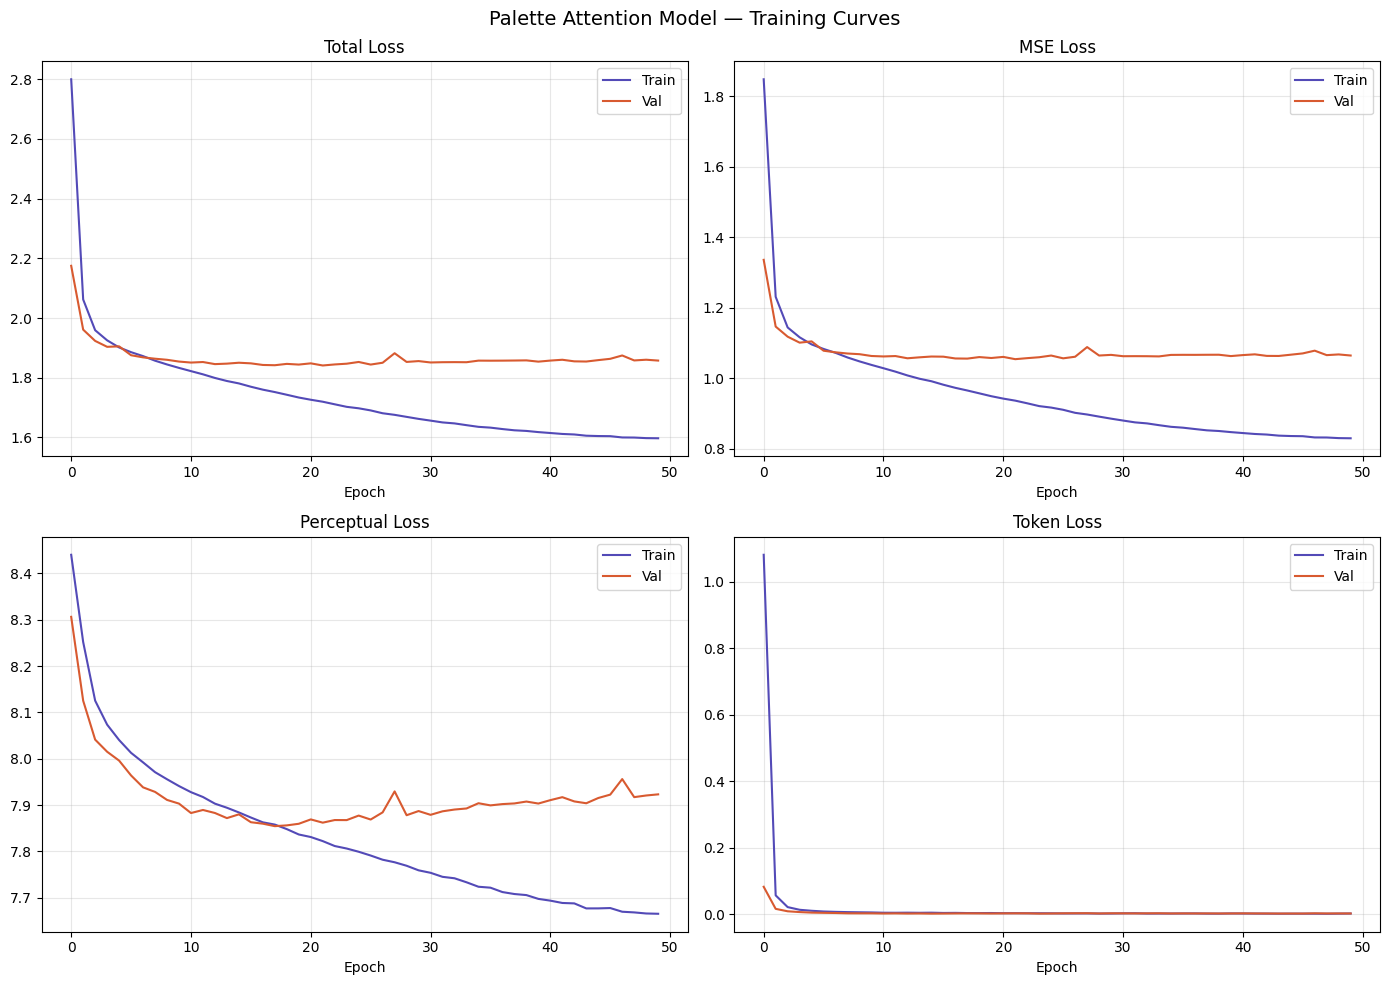

Training curves saved!


In [10]:
# Cell 10 — Plot loss curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].plot(history['train_loss'], label='Train', color='#534AB7')
axes[0][0].plot(history['val_loss'],   label='Val',   color='#D85A30')
axes[0][0].set_title('Total Loss')
axes[0][0].set_xlabel('Epoch')
axes[0][0].legend()
axes[0][0].grid(alpha=0.3)

axes[0][1].plot(history['train_mse'], label='Train', color='#534AB7')
axes[0][1].plot(history['val_mse'],   label='Val',   color='#D85A30')
axes[0][1].set_title('MSE Loss')
axes[0][1].set_xlabel('Epoch')
axes[0][1].legend()
axes[0][1].grid(alpha=0.3)

axes[1][0].plot(history['train_perceptual'], label='Train', color='#534AB7')
axes[1][0].plot(history['val_perceptual'],   label='Val',   color='#D85A30')
axes[1][0].set_title('Perceptual Loss')
axes[1][0].set_xlabel('Epoch')
axes[1][0].legend()
axes[1][0].grid(alpha=0.3)

axes[1][1].plot(history['train_token'], label='Train', color='#534AB7')
axes[1][1].plot(history['val_token'],   label='Val',   color='#D85A30')
axes[1][1].set_title('Token Loss')
axes[1][1].set_xlabel('Epoch')
axes[1][1].legend()
axes[1][1].grid(alpha=0.3)

plt.suptitle('Palette Attention Model — Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved!")

Loaded best model from epoch 22
Best val loss: 1.8409


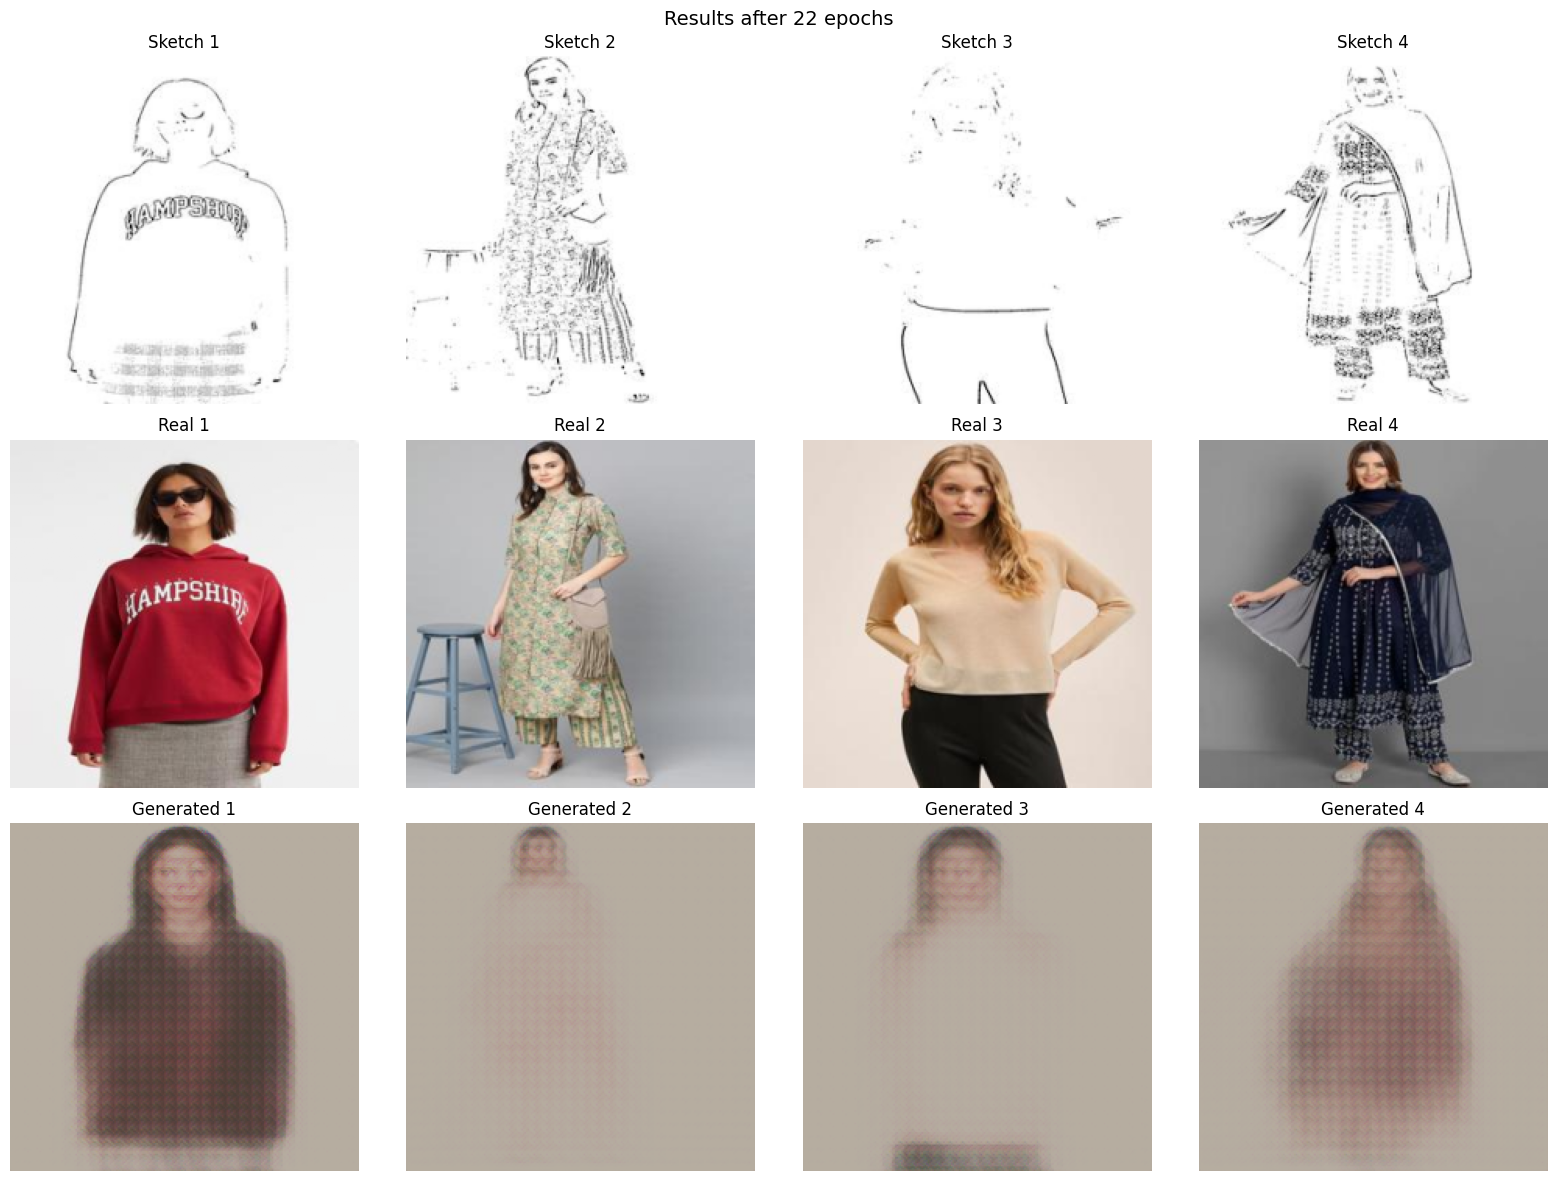

Results saved!


In [11]:
# Cell 11 — Visual check after training
from torchvision.utils import make_grid

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(tensor.device)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(tensor.device)
    return torch.clamp(tensor * std + mean, 0, 1)

# load best model
checkpoint = torch.load('/kaggle/working/checkpoints/best_model.pt',
                        map_location=device)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best val loss: {checkpoint['val_loss']:.4f}")

batch        = next(iter(val_loader))
sketches     = batch['sketch'].to(device)
images       = batch['image'].to(device)
colour_idx   = batch['colour_idx'].to(device)
category_idx = batch['category_idx'].to(device)

with torch.no_grad():
    outfits, _, _, _ = model(sketches, colour_idx, category_idx)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(4):
    # sketch
    axes[0][i].imshow(sketches[i].cpu().squeeze(), cmap='gray')
    axes[0][i].set_title(f'Sketch {i+1}')
    axes[0][i].axis('off')

    # real outfit
    real_np = denormalize(images[i].cpu()).permute(1,2,0).numpy()
    axes[1][i].imshow(real_np)
    axes[1][i].set_title(f'Real {i+1}')
    axes[1][i].axis('off')

    # generated outfit
    gen_np = denormalize(outfits[i].cpu()).permute(1,2,0).numpy()
    axes[2][i].imshow(gen_np)
    axes[2][i].set_title(f'Generated {i+1}')
    axes[2][i].axis('off')

plt.suptitle(f'Results after {checkpoint["epoch"]} epochs', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/trained_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results saved!")

In [12]:
# Cell 12 — Save history
import json
with open('/kaggle/working/training_history.json', 'w') as f:
    json.dump(history, f)
print("Training history saved!")
print(f"\nFinal summary:")
print(f"  Best epoch    : {best_epoch}")
print(f"  Best val loss : {best_val_loss:.4f}")
print(f"  Final train   : {history['train_loss'][-1]:.4f}")
print(f"  Final val     : {history['val_loss'][-1]:.4f}")

Training history saved!

Final summary:
  Best epoch    : 22
  Best val loss : 1.8409
  Final train   : 1.5970
  Final val     : 1.8574
